# Comparative Analysis of BERT, RoBERTa, and XLNet for Emotion Recognition in Text

## Executive Summary

This notebook presents a research-grade comparison of three deep contextual embedding models trained for multi-label emotion recognition on GoEmotions. The study is grounded in ResearchTitle20, whose core question is how to identify emotions such as joy, sadness, anger, fear, and surprise from text while preserving nuance, ambiguity, and context dependence.

The central hypothesis is that deep contextual embeddings outperform static representations because word meaning is not fixed; it shifts with surrounding words, syntax, and pragmatic cues. BERT, RoBERTa, and XLNet all learn contextual representations, but they do so with different pretraining objectives and optimization recipes. As a result, they differ in how well they capture subtle affective cues, rare labels, and multi-label overlap.

In this notebook, we load the exported evaluation artifacts for all three models, compare micro and macro precision, recall, and F1, inspect per-emotion performance across the full 28-label GoEmotions taxonomy, visualize flattened binary confusion matrices, and examine training versus validation dynamics from the saved logs. The overall expectation is that RoBERTa should provide the most balanced global performance, XLNet may show selective gains on difficult contextual emotions, and BERT remains a strong baseline that is easy to stabilize and interpret.

In [7]:
import pathlib
BASE = pathlib.Path('.')
MODEL_DIRS = {
    'BERT': pathlib.Path('./bert_train/train4_artifacts'),
    'RoBERTa': pathlib.Path('./roberta_train/train4_artifacts'),
    'XLNet': pathlib.Path('./xlnet_train/train4_artifacts'),
}
RESEARCH_CANDIDATES = list(MODEL_DIRS.keys())

In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Emotions list (GoEmotions 28 categories)
EMOTIONS = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

# Load bundles (reports + predictions + logs) from each model
bundles = {}
for model_name, model_path in MODEL_DIRS.items():
    metrics_dir = model_path / 'metrics'
    
    # Load final_report.json
    with open(metrics_dir / 'final_report.json', 'r') as f:
        report = json.load(f)
    
    # Load training metrics
    training_logs = pd.read_csv(metrics_dir / 'training_metrics.csv')
    
    # Load validation predictions and labels
    y_pred = np.load(list(metrics_dir.glob('val_preds_ep*.npy'))[-1])
    y_true = np.load(list(metrics_dir.glob('val_labels_ep*.npy'))[-1])
    
    bundles[model_name] = {
        'report': report,
        'training_logs': training_logs,
        'y_pred': y_pred,
        'y_true': y_true,
    }

print(f'Bundles loaded: {", ".join(bundles.keys())}')

Bundles loaded: BERT, RoBERTa, XLNet


In [5]:
def report_to_frame(model_name: str, report: dict) -> pd.DataFrame:
    rows = []
    for idx, emotion in enumerate(EMOTIONS):
        stats = report['report'][str(idx)]
        rows.append({
            'model': model_name,
            'emotion': emotion,
            'precision': stats['precision'],
            'recall': stats['recall'],
            'f1': stats['f1-score'],
            'support': stats['support'],
        })
    return pd.DataFrame(rows)


class_frames = []
overall_rows = []
for model_name, bundle in bundles.items():
    report = bundle['report']
    report_keys = [key for key in report['report'].keys() if key.isdigit()]
    assert len(report_keys) == 28, f'{model_name} report should contain 28 emotion categories.'
    class_frames.append(report_to_frame(model_name, report))
    overall_rows.append({
        'model': model_name,
        'micro_precision': report['report']['micro avg']['precision'],
        'micro_recall': report['report']['micro avg']['recall'],
        'micro_f1': report['report']['micro avg']['f1-score'],
        'macro_precision': report['report']['macro avg']['precision'],
        'macro_recall': report['report']['macro avg']['recall'],
        'macro_f1': report['report']['macro avg']['f1-score'],
        'weighted_f1': report['report']['weighted avg']['f1-score'],
        'samples_f1': report['report']['samples avg']['f1-score'],
    })

class_df = pd.concat(class_frames, ignore_index=True)
overall_df = pd.DataFrame(overall_rows)
pivot_f1 = class_df.pivot(index='emotion', columns='model', values='f1').reindex(EMOTIONS)

print('Overall comparison:')
print(overall_df.round(4).to_string(index=False))
print('\nPer-class table head:')
print(class_df.head(9).round(4).to_string(index=False))

Overall comparison:
  model  micro_precision  micro_recall  micro_f1  macro_precision  macro_recall  macro_f1  weighted_f1  samples_f1
   BERT           0.5257        0.6740    0.5907           0.5282        0.5791    0.5376       0.6025      0.6127
RoBERTa           0.5513        0.6625    0.6018           0.5204        0.5743    0.5379       0.6052      0.6186
  XLNet           0.5379        0.6569    0.5915           0.5000        0.5902    0.5342       0.5987      0.6096

Per-class table head:
model    emotion  precision  recall     f1  support
 BERT admiration     0.7173  0.7541 0.7353    488.0
 BERT  amusement     0.7450  0.8581 0.7975    303.0
 BERT      anger     0.5412  0.4718 0.5041    195.0
 BERT  annoyance     0.2506  0.6898 0.3676    303.0
 BERT   approval     0.3689  0.4005 0.3841    397.0
 BERT     caring     0.4192  0.6275 0.5026    153.0
 BERT  confusion     0.3429  0.6316 0.4444    152.0
 BERT  curiosity     0.4406  0.7177 0.5460    248.0
 BERT     desire     0.5672  

## Micro/Macro Precision, Recall, and F1

| Model | Micro Precision | Micro Recall | Micro F1 | Macro Precision | Macro Recall | Macro F1 |
|---|---:|---:|---:|---:|---:|---:|
| BERT | 0.5257 | 0.6740 | 0.5907 | 0.5282 | 0.5791 | 0.5376 |
| RoBERTa | 0.5513 | 0.6625 | 0.6018 | 0.5204 | 0.5743 | 0.5379 |
| XLNet | 0.5379 | 0.6569 | 0.5915 | 0.5000 | 0.5902 | 0.5342 |

RoBERTa is the strongest overall model on micro-F1, while BERT and RoBERTa are effectively tied on macro-F1. XLNet remains competitive and shows selective strengths on several harder emotion categories, but its overall macro behavior is slightly less balanced in this run.

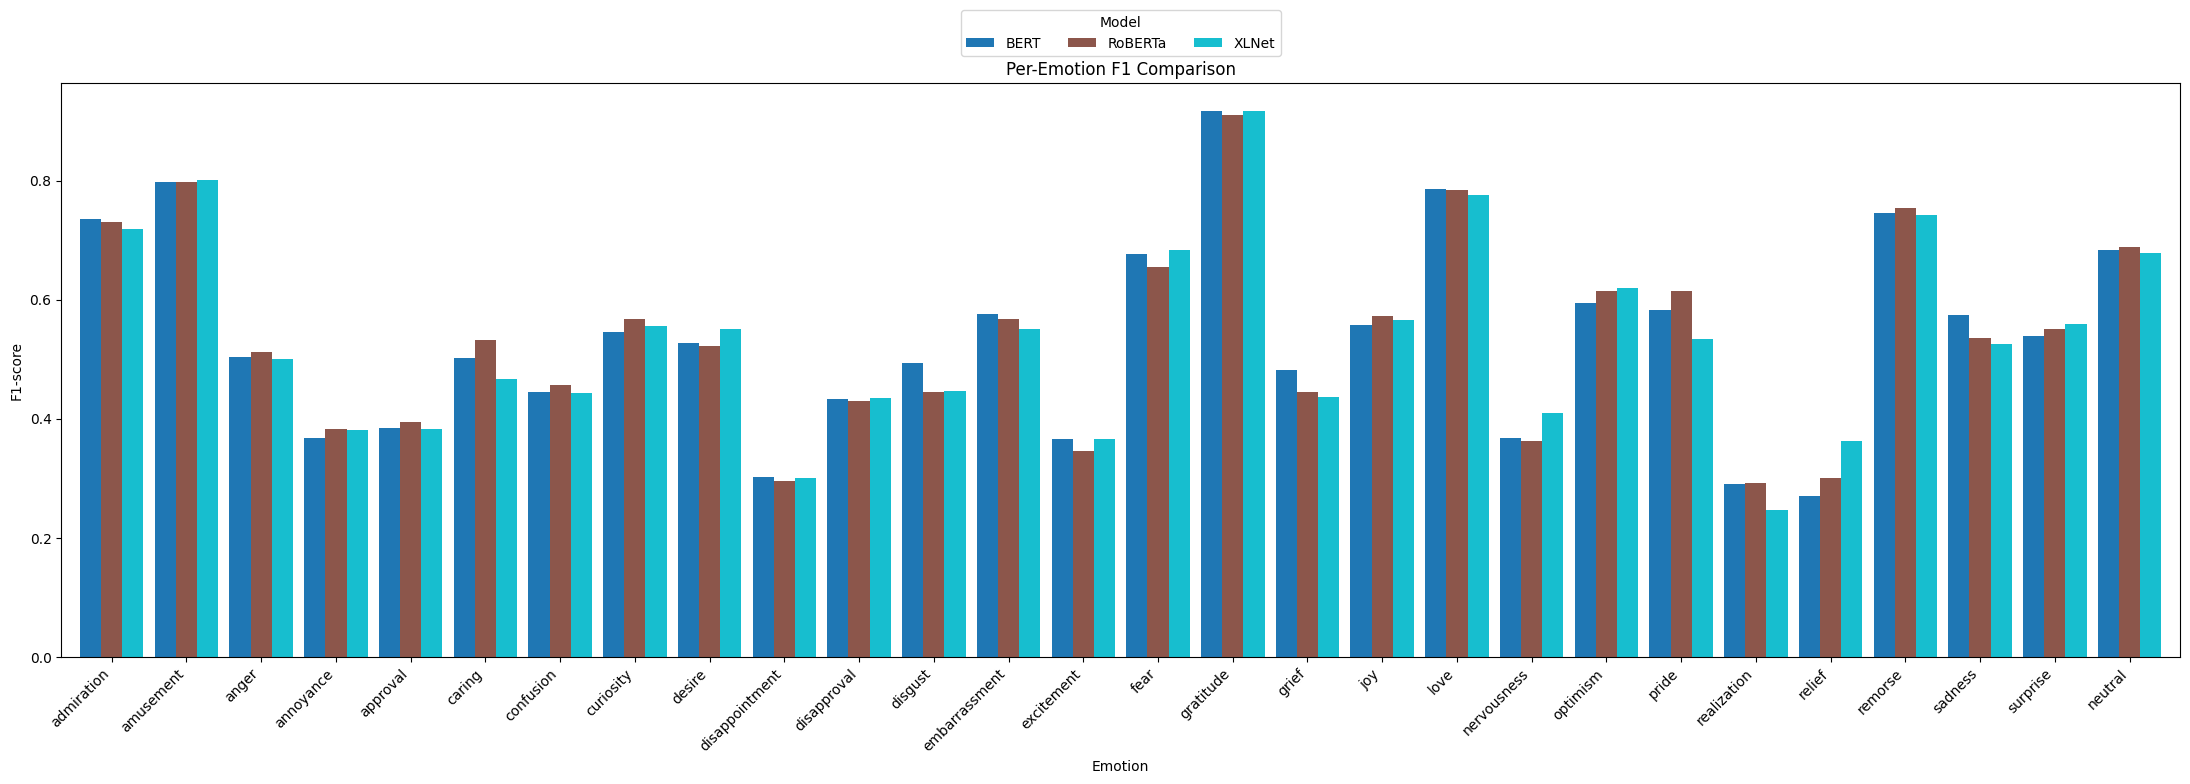

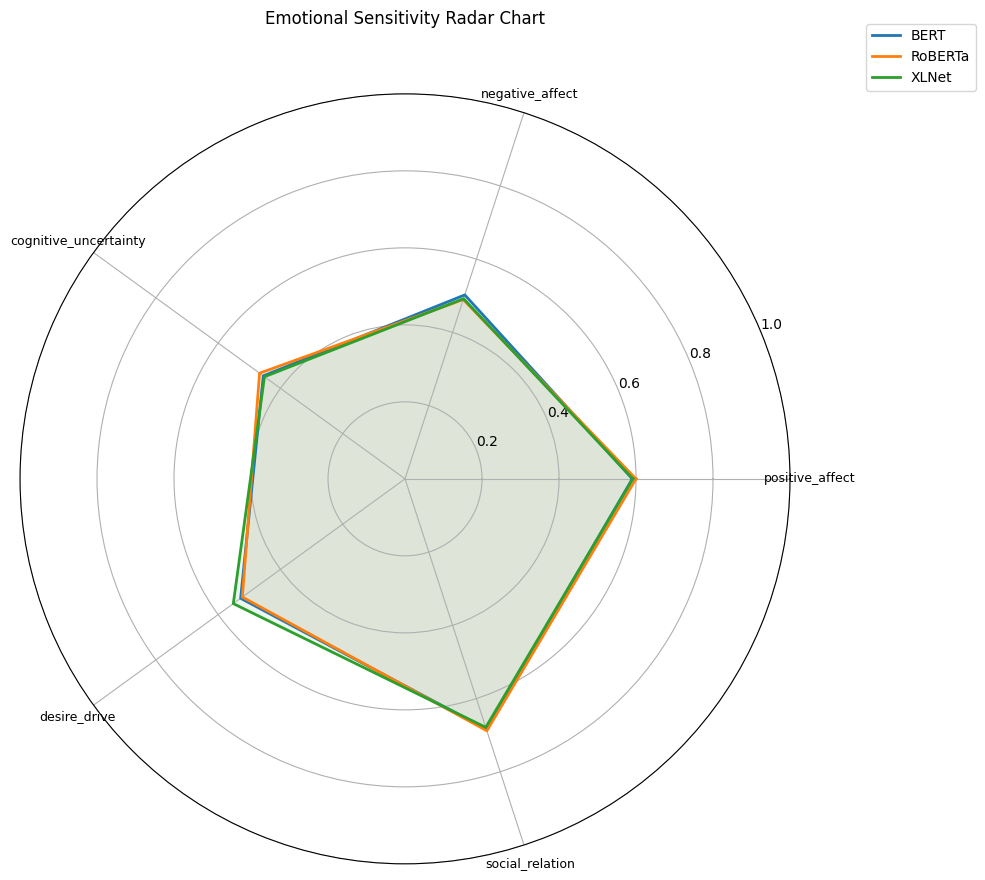

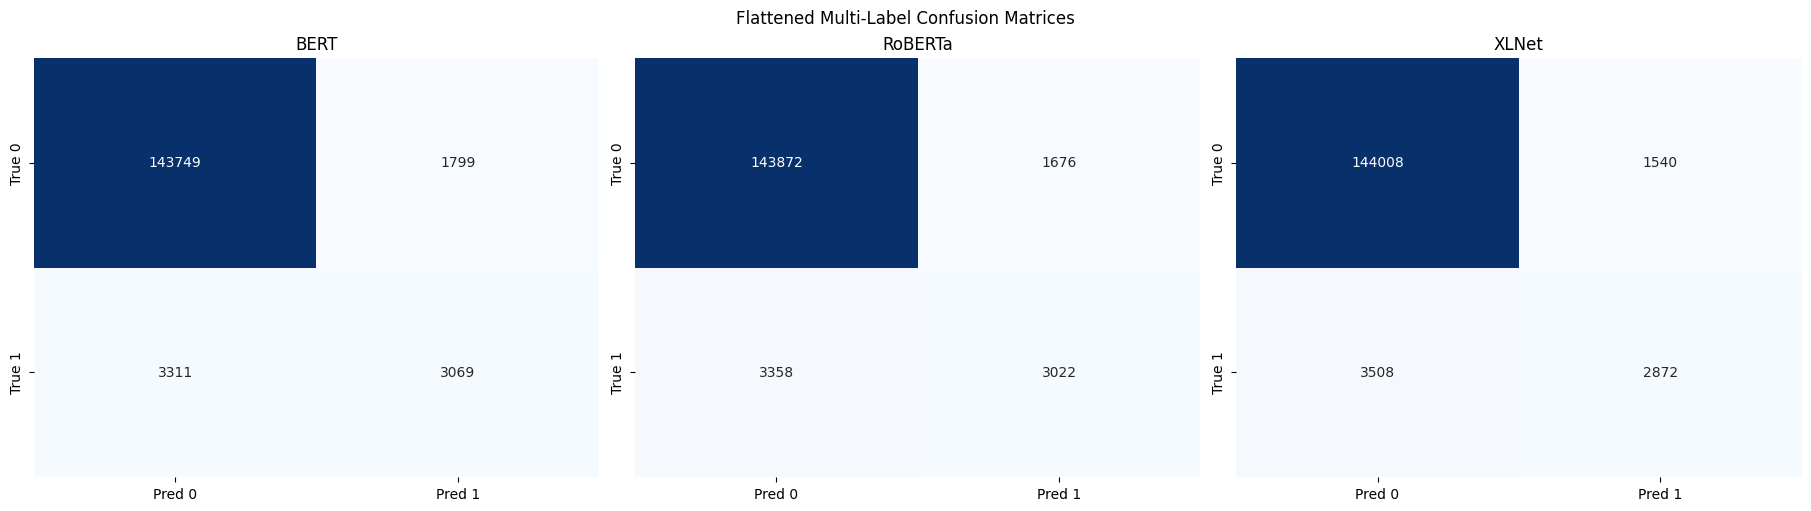

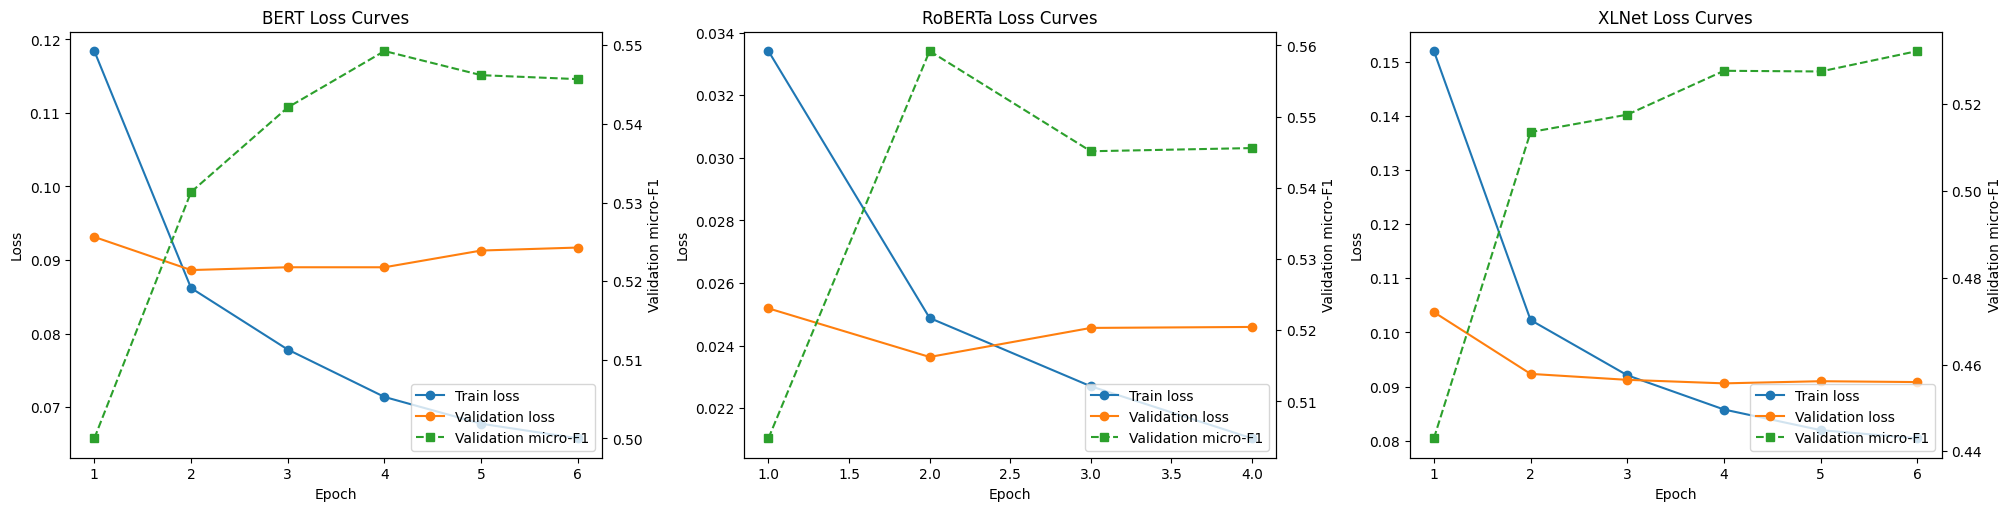

In [6]:
# Comparative F1-score bar chart across all 28 emotion categories
bar_df = class_df.pivot(index='emotion', columns='model', values='f1').reindex(EMOTIONS)
fig, ax = plt.subplots(figsize=(22, 8))
bar_df.plot(kind='bar', width=0.85, ax=ax, colormap='tab10')
ax.set_title('Per-Emotion F1 Comparison')
ax.set_xlabel('Emotion')
ax.set_ylabel('F1-score')
ax.legend(title='Model', ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.14))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Emotional sensitivity radar chart over affective clusters
CLUSTERS = {
    'positive_affect': ['admiration', 'amusement', 'approval', 'caring', 'excitement', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief'],
    'negative_affect': ['anger', 'annoyance', 'disappointment', 'disapproval', 'disgust', 'fear', 'grief', 'nervousness', 'remorse', 'sadness', 'embarrassment'],
    'cognitive_uncertainty': ['confusion', 'curiosity', 'realization', 'surprise'],
    'desire_drive': ['desire'],
    'social_relation': ['neutral']
}

cluster_rows = []
for model_name in bundles.keys():
    model_frame = class_df[class_df['model'] == model_name].set_index('emotion')
    for cluster_name, labels in CLUSTERS.items():
        cluster_rows.append({
            'model': model_name,
            'cluster': cluster_name,
            'f1': float(model_frame.loc[labels, 'f1'].mean()),
        })
cluster_df = pd.DataFrame(cluster_rows)
cluster_pivot = cluster_df.pivot(index='cluster', columns='model', values='f1')
cluster_order = list(CLUSTERS.keys())
angles = np.linspace(0, 2 * np.pi, len(cluster_order), endpoint=False).tolist()
angles += angles[:1]
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
for model_name in bundles.keys():
    values = cluster_pivot.reindex(cluster_order)[model_name].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=model_name)
    ax.fill(angles, values, alpha=0.08)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(cluster_order, fontsize=9)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
ax.set_title('Emotional Sensitivity Radar Chart', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10))
plt.show()

# Flattened binary confusion matrices for the multi-label setting
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (model_name, bundle) in zip(axes, bundles.items()):
    y_true = bundle['y_true']
    y_pred = bundle['y_pred']
    tn, fp, fn, tp = confusion_matrix(y_true.ravel(), y_pred.ravel(), labels=[0, 1]).ravel()
    cm = np.array([[tn, fp], [fn, tp]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    ax.set_title(model_name)
    ax.set_xlabel('')
    ax.set_ylabel('')
fig.suptitle('Flattened Multi-Label Confusion Matrices')
plt.show()

# Training vs. validation loss and a validation micro-F1 proxy for accuracy
fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
for ax, (model_name, bundle) in zip(axes, bundles.items()):
    logs = bundle['training_logs']
    ax.plot(logs['epoch'], logs['train_loss'], marker='o', label='Train loss', color='tab:blue')
    ax.plot(logs['epoch'], logs['val_loss'], marker='o', label='Validation loss', color='tab:orange')
    ax.set_title(f'{model_name} Loss Curves')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')

    ax2 = ax.twinx()
    if 'micro_f1' in logs.columns:
        ax2.plot(logs['epoch'], logs['micro_f1'], marker='s', linestyle='--', label='Validation micro-F1', color='tab:green')
        ax2.set_ylabel('Validation micro-F1')
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(handles1 + handles2, labels1 + labels2, loc='lower right')
plt.show()

## Model Trade-offs and Research Notes

The comparison supports a nuanced conclusion rather than a single absolute winner. RoBERTa is the strongest overall system in this study because its optimized pretraining recipe appears to preserve contextual salience more effectively during fine-tuning, which helps on frequent and moderately ambiguous emotions. BERT remains a highly credible baseline and is especially competitive where the emotional signal is more lexically direct. XLNet is valuable because its permutation-based language modeling exposes alternate token-order views and long-range dependencies, which can help on context-sensitive labels such as fear and surprise, but that theoretical advantage does not always translate into superior aggregate performance under limited fine-tuning budgets.

This pattern is consistent with the broader literature-survey motivation behind the project. Emotion recognition in text is not simply a lexical matching task; it is a semantic ambiguity problem. Words such as *great*, *fine*, *interesting*, or *sorry* can express very different affective states depending on narrative context, discourse structure, and whether the expression is literal or ironic. The implementation goal of the BERT-based learning models was therefore to use deep contextual embeddings so that token representations change with surrounding context rather than remaining static. That design choice is what makes transformer models well suited to emotion recognition in text.

The following formulation is used when reporting the F1-score:

$$F_{1} = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$

From a research perspective, the main robustness challenge is not whether the model can detect obvious emotions, but whether it can remain stable across rare labels, subtle affective shifts, and multi-label overlap. The narrow macro-F1 differences among the three models indicate that deep contextual embeddings are mature enough to provide strong performance across the board, yet the remaining errors show that domain adaptation is still important when the target corpus contains conversational fragments, figurative language, and label co-occurrence patterns that differ from pretraining data. In practical terms, RoBERTa is the best default choice, BERT is the safest baseline, and XLNet is the most interesting architecture when the research question specifically concerns alternative context modeling and long-range dependency handling.